# **Projet final : Student** **Performance**

## Etape 1 : Importer les packages et charger les CSV

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
# 1. Charger les données
df_m = pd.read_csv('/content/student-mat.csv', sep=';')
df_p = pd.read_csv('/content/student-por.csv', sep=';')


##Etape 2 : Analyse des dataframes

In [3]:
# Afficher toutes les colonnes sans césure
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

In [4]:
# Analyse DataFrame Math
df_m.head(10)        # 10 premières lignes

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10
5,GP,M,16,U,LE3,T,4,3,services,other,reputation,mother,1,2,0,no,yes,yes,yes,yes,yes,yes,no,5,4,2,1,2,5,10,15,15,15
6,GP,M,16,U,LE3,T,2,2,other,other,home,mother,1,2,0,no,no,no,no,yes,yes,yes,no,4,4,4,1,1,3,0,12,12,11
7,GP,F,17,U,GT3,A,4,4,other,teacher,home,mother,2,2,0,yes,yes,no,no,yes,yes,no,no,4,1,4,1,1,1,6,6,5,6
8,GP,M,15,U,LE3,A,3,2,services,other,home,mother,1,2,0,no,yes,yes,no,yes,yes,yes,no,4,2,2,1,1,1,0,16,18,19
9,GP,M,15,U,GT3,T,3,4,other,other,home,mother,1,2,0,no,yes,yes,yes,yes,yes,yes,no,5,5,1,1,1,5,0,14,15,15


In [5]:
# Analyse DataFrame Portuguais
df_p.head(10)        # 10 premières lignes

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,0,yes,no,no,no,yes,yes,yes,no,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,no,yes,yes,yes,yes,yes,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,no,no,yes,yes,no,no,4,3,2,1,2,5,0,11,13,13
5,GP,M,16,U,LE3,T,4,3,services,other,reputation,mother,1,2,0,no,yes,no,yes,yes,yes,yes,no,5,4,2,1,2,5,6,12,12,13
6,GP,M,16,U,LE3,T,2,2,other,other,home,mother,1,2,0,no,no,no,no,yes,yes,yes,no,4,4,4,1,1,3,0,13,12,13
7,GP,F,17,U,GT3,A,4,4,other,teacher,home,mother,2,2,0,yes,yes,no,no,yes,yes,no,no,4,1,4,1,1,1,2,10,13,13
8,GP,M,15,U,LE3,A,3,2,services,other,home,mother,1,2,0,no,yes,no,no,yes,yes,yes,no,4,2,2,1,1,1,0,15,16,17
9,GP,M,15,U,GT3,T,3,4,other,other,home,mother,1,2,0,no,yes,no,yes,yes,yes,yes,no,5,5,1,1,1,5,0,12,12,13


In [6]:
df_m.tail(5)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
390,MS,M,20,U,LE3,A,2,2,services,services,course,other,1,2,2,no,yes,yes,no,yes,yes,no,no,5,5,4,4,5,4,11,9,9,9
391,MS,M,17,U,LE3,T,3,1,services,services,course,mother,2,1,0,no,no,no,no,no,yes,yes,no,2,4,5,3,4,2,3,14,16,16
392,MS,M,21,R,GT3,T,1,1,other,other,course,other,1,1,3,no,no,no,no,no,yes,no,no,5,5,3,3,3,3,3,10,8,7
393,MS,M,18,R,LE3,T,3,2,services,other,course,mother,3,1,0,no,no,no,no,no,yes,yes,no,4,4,1,3,4,5,0,11,12,10
394,MS,M,19,U,LE3,T,1,1,other,at_home,course,father,1,1,0,no,no,no,no,yes,yes,yes,no,3,2,3,3,3,5,5,8,9,9


In [7]:
df_p.tail(5)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
644,MS,F,19,R,GT3,T,2,3,services,other,course,mother,1,3,1,no,no,no,yes,no,yes,yes,no,5,4,2,1,2,5,4,10,11,10
645,MS,F,18,U,LE3,T,3,1,teacher,services,course,mother,1,2,0,no,yes,no,no,yes,yes,yes,no,4,3,4,1,1,1,4,15,15,16
646,MS,F,18,U,GT3,T,1,1,other,other,course,mother,2,2,0,no,no,no,yes,yes,yes,no,no,1,1,1,1,1,5,6,11,12,9
647,MS,M,17,U,LE3,T,3,1,services,services,course,mother,2,1,0,no,no,no,no,no,yes,yes,no,2,4,5,3,4,2,6,10,10,10
648,MS,M,18,R,LE3,T,3,2,services,other,course,mother,3,1,0,no,no,no,no,no,yes,yes,no,4,4,1,3,4,5,4,10,11,11


In [8]:
df_m.info()          # types + valeurs manquantes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [9]:
df_p.info()          # types + valeurs manquantes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null    object
 20  higher    

In [10]:
df_m.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [11]:
df_p.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


In [12]:
df_m[df_m.duplicated()]      # affiche les lignes en doublon

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3


In [13]:
df_p[df_p.duplicated()]      # affiche les lignes en doublon

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3


## Etape 3 : Renommer les colonnes et ajout de la colonne "cours". Fusion des datasets



In [14]:
# Ajout de la colonne cours
df_m["cours"] = "maths"
df_p["cours"] = "portuguais"

In [15]:
# Création de la fonction pour renommer les colonnes
renommer_colonnes = { "school": "etablissement", "sex": "sexe", "age": "age", "address": "type_domicile", "famsize": "taille_famille", "Pstatus": "statut_parents",
                    "Medu": "niveau_education_mere", "Fedu": "niveau_education_pere", "Mjob": "profession_mere", "Fjob": "profession_pere", "reason": "motif_choix_etablissement",
                    "guardian": "tuteur", "traveltime": "temps_trajet_domicile_ecole", "studytime": "temps_etude_hebdomadaire", "failures": "redoublements", "schoolsup": "soutien_scolaire",
                    "famsup": "soutien_familial", "paid": "cours_payants", "activities": "activites_extrascolaires", "nursery": "creche", "higher": "projet_etudes_superieures",
                    "internet": "acces_internet_domicile", "romantic": "relation_amoureuse", "famrel": "qualite_relations_familiales", "freetime": "temps_libre", "goout": "sorties_amis",
                    "Dalc": "conso_alcool_jour_ouvre", "Walc": "conso_alcool_weekend", "health": "etat_sante", "absences": "nombre_absences", "cours" : "cours" }

df_m = df_m.rename(columns=renommer_colonnes)
df_p = df_p.rename(columns=renommer_colonnes)

Nous avons décidé d'effectuer un merge au lieu d'un concat afin d'avoir un seul étudiant par ligne.

In [16]:
# Fusion des datasets grâce au merge
MergeList = ["etablissement", "sexe", "age", "type_domicile", "taille_famille",
       "statut_parents", "niveau_education_mere", "niveau_education_pere",
       "profession_mere", "profession_pere", "motif_choix_etablissement",
       "creche", "acces_internet_domicile", "tuteur",
       "temps_trajet_domicile_ecole", "projet_etudes_superieures",
       "qualite_relations_familiales", "temps_libre", "sorties_amis", "conso_alcool_weekend","conso_alcool_jour_ouvre","relation_amoureuse","etat_sante"]
df_final = pd.merge(df_m,df_p, how = 'outer', on = MergeList,suffixes=("_math", "_por"))
df_final.shape

(674, 45)

In [17]:
print(df_final.columns)

Index(['etablissement', 'sexe', 'age', 'type_domicile', 'taille_famille',
       'statut_parents', 'niveau_education_mere', 'niveau_education_pere',
       'profession_mere', 'profession_pere', 'motif_choix_etablissement',
       'tuteur', 'temps_trajet_domicile_ecole',
       'temps_etude_hebdomadaire_math', 'redoublements_math',
       'soutien_scolaire_math', 'soutien_familial_math', 'cours_payants_math',
       'activites_extrascolaires_math', 'creche', 'projet_etudes_superieures',
       'acces_internet_domicile', 'relation_amoureuse',
       'qualite_relations_familiales', 'temps_libre', 'sorties_amis',
       'conso_alcool_jour_ouvre', 'conso_alcool_weekend', 'etat_sante',
       'nombre_absences_math', 'G1_math', 'G2_math', 'G3_math', 'cours_math',
       'temps_etude_hebdomadaire_por', 'redoublements_por',
       'soutien_scolaire_por', 'soutien_familial_por', 'cours_payants_por',
       'activites_extrascolaires_por', 'nombre_absences_por', 'G1_por',
       'G2_por', 'G3_por'

In [18]:
df_final

,etablissement,sexe,age,type_domicile,taille_famille,statut_parents,niveau_education_mere,niveau_education_pere,profession_mere,profession_pere,motif_choix_etablissement,tuteur,temps_trajet_domicile_ecole,temps_etude_hebdomadaire_math,redoublements_math,soutien_scolaire_math,soutien_familial_math,cours_payants_math,activites_extrascolaires_math,creche,projet_etudes_superieures,acces_internet_domicile,relation_amoureuse,qualite_relations_familiales,temps_libre,sorties_amis,conso_alcool_jour_ouvre,conso_alcool_weekend,etat_sante,nombre_absences_math,G1_math,G2_math,G3_math,cours_math,temps_etude_hebdomadaire_por,redoublements_por,soutien_scolaire_por,soutien_familial_por,cours_payants_por,activites_extrascolaires_por,nombre_absences_por,G1_por,G2_por,G3_por,cours_por
0,GP,F,15,R,GT3,T,1,1,at_home,other,home,mother,2,4.0,1.0,yes,yes,yes,yes,yes,yes,yes,no,3,1,2,1,1,1,2.0,7.0,10.0,10.0,maths,4.0,0.0,yes,yes,yes,yes,4.0,13.0,13.0,13.0,portuguais
1,GP,F,15,R,GT3,T,1,1,other,other,course,mother,3,NaN,NaN,NaN,NaN,NaN,NaN,yes,yes,yes,yes,5,5,5,1,1,1,NaN,NaN,NaN,NaN,NaN,1.0,1.0,no,no,no,yes,2.0,8.0,9.0,9.0,portuguais
2,GP,F,15,R,GT3,T,1,1,other,other,reputation,mother,1,2.0,2.0,yes,yes,no,no,no,yes,yes,yes,3,3,4,2,4,5,2.0,8.0,6.0,5.0,maths,2.0,0.0,yes,yes,no,no,2.0,13.0,11.0,11.0,portuguais
3,GP,F,15,R,GT3,T,2,2,at_home,other,reputation,mother,1,1.0,0.0,yes,yes,yes,yes,yes,yes,no,no,4,3,1,1,1,2,8.0,14.0,13.0,13.0,maths,1.0,0.0,yes,yes,no,yes,8.0,14.0,13.0,12.0,portuguais
4,GP,F,15,R,GT3,T,2,4,services,health,course,mother,1,3.0,0.0,yes,yes,yes,yes,yes,yes,yes,no,4,3,2,1,1,5,2.0,10.0,9.0,8.0,maths,3.0,0.0,yes,yes,no,yes,2.0,10.0,11.0,10.0,portuguais
5,GP,F,15,R,GT3,T,3,3,services,services,reputation,other,2,3.0,2.0,no,yes,yes,yes,yes,yes,yes,yes,4,2,1,2,3,3,8.0,10.0,10.0,10.0,maths,3.0,0.0,no,yes,yes,yes,2.0,13.0,13.0,13.0,portuguais
6,GP,F,15,R,GT3,T,3,4,services,health,course,mother,1,3.0,0.0,yes,yes,yes,yes,yes,yes,yes,no,4,3,2,1,1,5,2.0,12.0,12.0,11.0,maths,3.0,0.0,yes,yes,no,yes,2.0,11.0,12.0,12.0,portuguais
7,GP,F,15,R,GT3,T,3,4,services,teacher,course,father,2,3.0,2.0,no,yes,no,no,yes,yes,yes,yes,4,2,2,2,2,5,0.0,12.0,0.0,0.0,maths,3.0,0.0,no,yes,no,no,0.0,10.0,11.0,12.0,portuguais
8,GP,F,15,R,LE3,T,2,2,health,services,reputation,mother,2,2.0,0.0,yes,yes,yes,no,yes,yes,yes,no,4,1,3,1,3,4,2.0,8.0,9.0,8.0,maths,2.0,0.0,yes,yes,no,no,0.0,11.0,10.0,11.0,portuguais
9,GP,F,15,R,LE3,T,3,1,other,other,reputation,father,2,4.0,0.0,no,yes,no,no,no,yes,yes,no,4,4,2,2,3,3,12.0,16.0,16.0,16.0,maths,4.0,0.0,no,yes,no,no,6.0,15.0,15.0,15.0,portuguais


## Etape 4 : Création d'une clé primaire

In [19]:
# Colonnes à utiliser pour la clé primaire
colonnes_cle = [
    "etablissement","sexe","age","type_domicile","taille_famille","statut_parents","niveau_education_mere","niveau_education_pere","profession_mere","profession_pere","motif_choix_etablissement","acces_internet_domicile", "creche",
 "conso_alcool_weekend","conso_alcool_jour_ouvre"]

# Fonction pour générer la clé primaire
def generer_cle_primaire(df, colonnes):
    df['cle_primaire'] = df[colonnes].astype(str).agg('|'.join, axis=1)
    return df

# Appliquer aux deux tables
data_final = generer_cle_primaire(df_final, colonnes_cle)


In [20]:
data_final.shape

(674, 46)

Vérification du nombre de valeurs uniques, nous constatons qu'il y a 3 valeurs dupliquées, cela peut s'expliquer par le fait que nous n'avons pas sélectionné les mêmes colonnes pour la clé primaire du merge. Nous n'avons sélectionné seulement des champs qui étaient "communs" aux deux matières.

---



In [21]:
df_unic = pd.DataFrame(data_final['cle_primaire'].unique())
df_unic

,0
0,GP|F|15|R|GT3|T|1|1|at_home|other|home|yes|yes...
1,GP|F|15|R|GT3|T|1|1|other|other|course|yes|yes...
2,GP|F|15|R|GT3|T|1|1|other|other|reputation|yes...
3,GP|F|15|R|GT3|T|2|2|at_home|other|reputation|n...
4,GP|F|15|R|GT3|T|2|4|services|health|course|yes...
5,GP|F|15|R|GT3|T|3|3|services|services|reputati...
6,GP|F|15|R|GT3|T|3|4|services|health|course|yes...
7,GP|F|15|R|GT3|T|3|4|services|teacher|course|ye...
8,GP|F|15|R|LE3|T|2|2|health|services|reputation...
9,GP|F|15|R|LE3|T|3|1|other|other|reputation|yes...


## Etape 5 : Transformation des valeurs catégorielles

Nous avons remplacé les valeurs numériques de certaines colonnes par des libellés textuels afin de faciliter la compréhension des regroupements effectués.  
Toutefois, certaines colonnes ont été conservées au format numérique afin de simplifier leur utilisation et leur intégration dans Power BI.

In [22]:
data_final_brut = data_final.copy()

In [23]:
# TRANSFORMATION DES COLONNES

# Sexe
data_final["sexe"] = data_final["sexe"].map({"F": "Féminin", "M": "Masculin"})

# Type de domicile
data_final["type_domicile"] = data_final["type_domicile"].map({"U": "Urbain", "R": "Rural"})

# Taille de la famille
data_final["taille_famille"] = data_final["taille_famille"].map({"LE3": "≤ 3 membres", "GT3": "> 3 membres"})

# Statut des parents
data_final["statut_parents"] = data_final["statut_parents"].map({"T": "Parents ensemble", "A": "Parents séparés"})

# Niveau d'éducation (mère et père)
data_final["niveau_education_mere"] = data_final["niveau_education_mere"].map({
    0: "Aucun", 1: "Primaire", 2: "Collège", 3: "Lycée", 4: "Supérieur"
})
data_final["niveau_education_pere"] = data_final["niveau_education_pere"].map({
    0: "Aucun", 1: "Primaire", 2: "Collège", 3: "Lycée", 4: "Supérieur"
})

# Profession (mère et père)
data_final["profession_mere"] = data_final["profession_mere"].map({
    "teacher": "Enseignant(e)",
    "health": "Santé (médecin, infirmier, etc.)",
    "services": "Services civiles (administration, police, etc.)",
    "other": "Autre",
    "at_home": "À la maison"
})
data_final["profession_pere"] = data_final["profession_pere"].map({
    "teacher": "Enseignant(e)",
    "health": "Santé (médecin, infirmier, etc.)",
    "services": "Services civiles (administration, police, etc.)",
    "other": "Autre",
    "at_home": "À la maison"
})

# Motif de choix de l'établissement
data_final["motif_choix_etablissement"] = data_final["motif_choix_etablissement"].map({
    "home": "proche_maison",
    "reputation": "réputation_ecole",
    "course": "préférence_matiere",
    "other": "Autre"
})

# Tuteur
data_final["tuteur"] = data_final["tuteur"].map({
    "mother": "Mère",
    "father": "Père",
    "other": "Autre"
})

# Temps de trajet domicile-école
data_final["temps_trajet_domicile_ecole"] = data_final["temps_trajet_domicile_ecole"].map({
    1: "<15 min", 2: "15 à 30 min", 3: "30 min à 1 heure", 4: ">1 heure"
})

# Temps d'étude hebdomadaire (math et por)
data_final["temps_etude_hebdomadaire_math"] = data_final["temps_etude_hebdomadaire_math"].map({
    1: "<2 heures", 2: "2 à 5 heures", 3: "5 à 10 heures", 4: ">10 heures"
})
data_final["temps_etude_hebdomadaire_por"] = data_final["temps_etude_hebdomadaire_por"].map({
    1: "<2 heures", 2: "2 à 5 heures", 3: "5 à 10 heures", 4: ">10 heures"
})

# Redoublements (math et por)
data_final["redoublements_math"] = data_final["redoublements_math"].map({
    0: "Aucun redoublement", 1: "1 redoublement", 2: "2 redoublements", 3: "3 redoublements ou plus"
})
data_final["redoublements_por"] = data_final["redoublements_por"].map({
    0: "Aucun redoublement", 1: "1 redoublement", 2: "2 redoublements", 3: "3 redoublements ou plus"
})

# Soutien scolaire (math et por)
data_final["soutien_scolaire_math"] = data_final["soutien_scolaire_math"].map({"yes": "Oui", "no": "Non"})
data_final["soutien_scolaire_por"] = data_final["soutien_scolaire_por"].map({"yes": "Oui", "no": "Non"})

# Soutien familial (math et por)
data_final["soutien_familial_math"] = data_final["soutien_familial_math"].map({"yes": "Oui", "no": "Non"})
data_final["soutien_familial_por"] = data_final["soutien_familial_por"].map({"yes": "Oui", "no": "Non"})

# Cours payants (math et por)
data_final["cours_payants_math"] = data_final["cours_payants_math"].map({"yes": "Oui", "no": "Non"})
data_final["cours_payants_por"] = data_final["cours_payants_por"].map({"yes": "Oui", "no": "Non"})

# Activités extrascolaires (math et por)
data_final["activites_extrascolaires_math"] = data_final["activites_extrascolaires_math"].map({"yes": "Oui", "no": "Non"})
data_final["activites_extrascolaires_por"] = data_final["activites_extrascolaires_por"].map({"yes": "Oui", "no": "Non"})

# Crèche et projet d'études supérieures
data_final["creche"] = data_final["creche"].map({"yes": "Oui", "no": "Non"})
data_final["projet_etudes_superieures"] = data_final["projet_etudes_superieures"].map({"yes": "Oui", "no": "Non"})

# Accès internet à domicile
data_final["acces_internet_domicile"] = data_final["acces_internet_domicile"].map({"yes": "Oui", "no": "Non"})

# Relation amoureuse
data_final["relation_amoureuse"] = data_final["relation_amoureuse"].map({"yes": "Oui", "no": "Non"})

# Qualité des relations familiales
data_final["qualite_relations_familiales_E"] = data_final["qualite_relations_familiales"].map({
    1: "Très mauvaise", 2: "Mauvaise", 3: "Moyenne", 4: "Bonne", 5: "Très bonne"})

# État de santé
data_final["etat_sante_E"] = data_final["etat_sante"].map({
    1: "Très mauvais", 2: "Mauvais", 3: "Moyen", 4: "Bon", 5: "Très bon"})

# Temps libre et sorties entre amis
data_final["temps_libre_E"] = data_final["temps_libre"].map({
    1: "Très peu", 2: "Peu", 3: "Moyen", 4: "Beaucoup", 5: "Enormément"
})
data_final["sorties_amis_E"] = data_final["sorties_amis"].map({
    1: "Très peu", 2: "Peu", 3: "Moyen", 4: "Beaucoup", 5: "Enormément"
})

# Consommation d'alcool - jour ouvré
data_final["conso_alcool_jour_ouvre_E"] = data_final["conso_alcool_jour_ouvre"].map({
    1: "Aucune", 2: "Faible", 3: "Modérée", 4: "Élevée", 5: "Très élevée"
})

# Consommation d'alcool - week-end
data_final["conso_alcool_weekend_E"] = data_final["conso_alcool_weekend"].map({
    1: "Aucune", 2: "Faible", 3: "Modérée", 4: "Élevée", 5: "Très élevée"
})

In [24]:
data_final.head()

,etablissement,sexe,age,type_domicile,taille_famille,statut_parents,niveau_education_mere,niveau_education_pere,profession_mere,profession_pere,motif_choix_etablissement,tuteur,temps_trajet_domicile_ecole,temps_etude_hebdomadaire_math,redoublements_math,soutien_scolaire_math,soutien_familial_math,cours_payants_math,activites_extrascolaires_math,creche,projet_etudes_superieures,acces_internet_domicile,relation_amoureuse,qualite_relations_familiales,temps_libre,sorties_amis,conso_alcool_jour_ouvre,conso_alcool_weekend,etat_sante,nombre_absences_math,G1_math,G2_math,G3_math,cours_math,temps_etude_hebdomadaire_por,redoublements_por,soutien_scolaire_por,soutien_familial_por,cours_payants_por,activites_extrascolaires_por,nombre_absences_por,G1_por,G2_por,G3_por,cours_por,cle_primaire,qualite_relations_familiales_E,etat_sante_E,temps_libre_E,sorties_amis_E,conso_alcool_jour_ouvre_E,conso_alcool_weekend_E
0,GP,Féminin,15,Rural,> 3 membres,Parents ensemble,Primaire,Primaire,À la maison,Autre,proche_maison,Mère,15 à 30 min,>10 heures,1 redoublement,Oui,Oui,Oui,Oui,Oui,Oui,Oui,Non,3,1,2,1,1,1,2.0,7.0,10.0,10.0,maths,>10 heures,Aucun redoublement,Oui,Oui,Oui,Oui,4.0,13.0,13.0,13.0,portuguais,GP|F|15|R|GT3|T|1|1|at_home|other|home|yes|yes...,Moyenne,Très mauvais,Très peu,Peu,Aucune,Aucune
1,GP,Féminin,15,Rural,> 3 membres,Parents ensemble,Primaire,Primaire,Autre,Autre,préférence_matiere,Mère,30 min à 1 heure,NaN,NaN,NaN,NaN,NaN,NaN,Oui,Oui,Oui,Oui,5,5,5,1,1,1,NaN,NaN,NaN,NaN,NaN,<2 heures,1 redoublement,Non,Non,Non,Oui,2.0,8.0,9.0,9.0,portuguais,GP|F|15|R|GT3|T|1|1|other|other|course|yes|yes...,Très bonne,Très mauvais,Enormément,Enormément,Aucune,Aucune
2,GP,Féminin,15,Rural,> 3 membres,Parents ensemble,Primaire,Primaire,Autre,Autre,réputation_ecole,Mère,<15 min,2 à 5 heures,2 redoublements,Oui,Oui,Non,Non,Non,Oui,Oui,Oui,3,3,4,2,4,5,2.0,8.0,6.0,5.0,maths,2 à 5 heures,Aucun redoublement,Oui,Oui,Non,Non,2.0,13.0,11.0,11.0,portuguais,GP|F|15|R|GT3|T|1|1|other|other|reputation|yes...,Moyenne,Très bon,Moyen,Beaucoup,Faible,Élevée
3,GP,Féminin,15,Rural,> 3 membres,Parents ensemble,Collège,Collège,À la maison,Autre,réputation_ecole,Mère,<15 min,<2 heures,Aucun redoublement,Oui,Oui,Oui,Oui,Oui,Oui,Non,Non,4,3,1,1,1,2,8.0,14.0,13.0,13.0,maths,<2 heures,Aucun redoublement,Oui,Oui,Non,Oui,8.0,14.0,13.0,12.0,portuguais,GP|F|15|R|GT3|T|2|2|at_home|other|reputation|n...,Bonne,Mauvais,Moyen,Très peu,Aucune,Aucune
4,GP,Féminin,15,Rural,> 3 membres,Parents ensemble,Collège,Supérieur,"Services civiles (administration, police, etc.)","Santé (médecin, infirmier, etc.)",préférence_matiere,Mère,<15 min,5 à 10 heures,Aucun redoublement,Oui,Oui,Oui,Oui,Oui,Oui,Oui,Non,4,3,2,1,1,5,2.0,10.0,9.0,8.0,maths,5 à 10 heures,Aucun redoublement,Oui,Oui,Non,Oui,2.0,10.0,11.0,10.0,portuguais,GP|F|15|R|GT3|T|2|4|services|health|course|yes...,Bonne,Très bon,Moyen,Peu,Aucune,Aucune


## Etape 6 : Création d'une colonne d'interprétation

Nous avons défini la réussite des étudiants à partir de leur note au troisième trimestre.

In [25]:
def statut_reussite(note):
    if pd.isna(note):
        return np.nan
    elif note == 0:
        return "Abandon"
    elif note >= 10:
        return "Réussite"
    else:
        return "Échec"

data_final["reussite_echec_math"] = data_final["G3_math"].apply(statut_reussite)

In [26]:
data_final["reussite_echec_por"] = data_final["G3_por"].apply(statut_reussite)

## Etape 7 : Téléchargement du CSV

In [27]:
data_final.to_csv('data_final.csv', index=False)

## Etape 8 : Création d'une heatmap

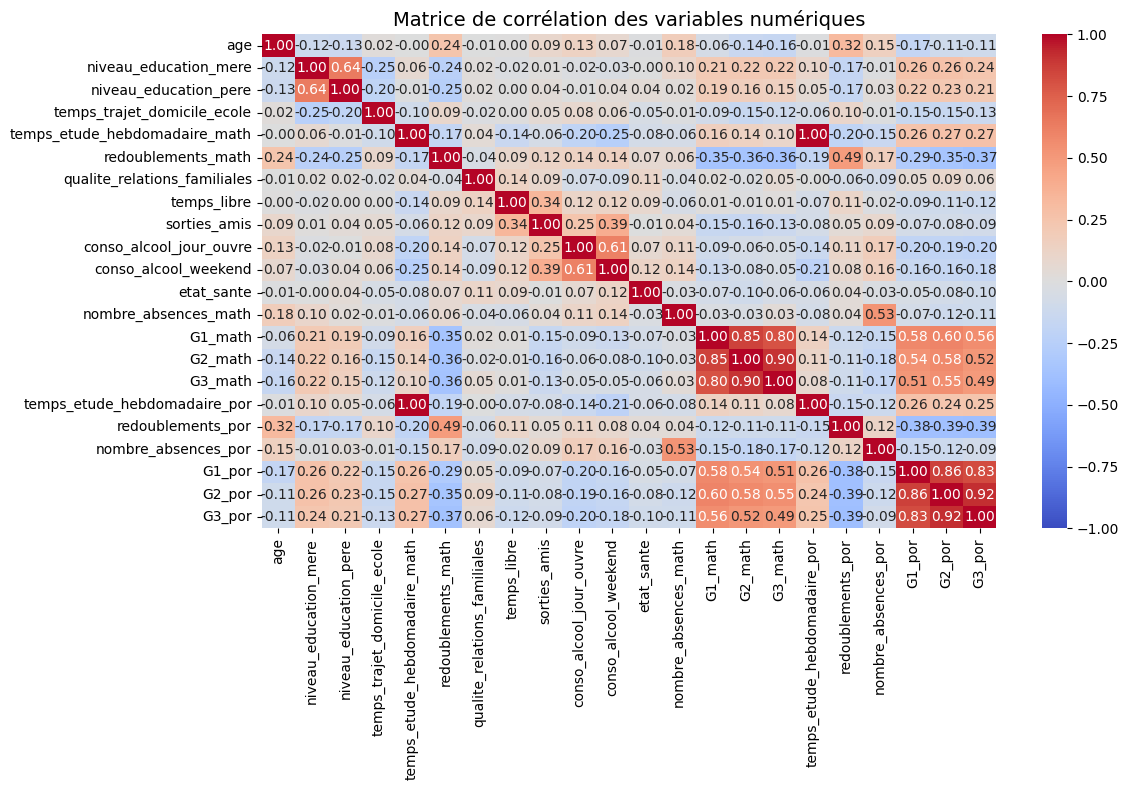

In [28]:
df_num = data_final_brut.select_dtypes(include="number")

corr = df_num.corr()

# Création de la heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
)
plt.title("Matrice de corrélation des variables numériques", fontsize=14)
plt.tight_layout()
plt.show()

## Etape 9 : Tests T

Si la p-value est inférieure à 0.05, il y a un écart probalement réel, sinon cela peut être dû au hasard et donc nous ne pouvons pas conclure.

In [29]:
# La différence de moyenne est-elle significative entre les étudiants de maths et Portugais ?
g3_math = data_final["G3_math"].dropna()
g3_por = data_final["G3_por"].dropna()

t_stat, p_value = stats.ttest_ind(g3_math, g3_por, equal_var=False)

print("Moyenne math :", round(g3_math.mean(), 2))
print("Moyenne portugais :", round(g3_por.mean(), 2))
print("p-value :", p_value)

Moyenne math : 10.42
Moyenne portugais : 11.91
p-value : 2.2150594938727083e-08


In [30]:
# Existe-il une différence significative de moyenne en mathématiques entre les étudiants de GP et MS ?
gp = data_final[data_final["etablissement"] == "GP"]["G3_math"].dropna()
ms = data_final[data_final["etablissement"] == "MS"]["G3_math"].dropna()

t_stat, p_value = stats.ttest_ind(gp, ms, equal_var=False)

print("Moyenne GP :", round(gp.mean(), 2))
print("Moyenne MS :", round(ms.mean(), 2))
print("p-value :", p_value, 4)

Moyenne GP : 10.49
Moyenne MS : 9.85
p-value : 0.34313169333140336 4


In [31]:
# Existe-il une différence significative de moyenne en portugais entre les étudiants de GP et MS ?
gp = data_final[data_final["etablissement"] == "GP"]["G3_por"].dropna()
ms = data_final[data_final["etablissement"] == "MS"]["G3_por"].dropna()

t_stat, p_value = stats.ttest_ind(gp, ms, equal_var=False)

print("Moyenne GP :", round(gp.mean(), 2))
print("Moyenne MS :", round(ms.mean(), 2))
print("p-value :", p_value, 4)

Moyenne GP : 12.58
Moyenne MS : 10.65
p-value : 6.211839408463177e-11 4


In [32]:
# Existe-il une différence significative de moyenne en mathématiques entre les étudiants vivants à la campagne et en ville?
rural = data_final[data_final["type_domicile"] == "Rural"]["G3_math"].dropna()
urbain = data_final[data_final["type_domicile"] == "Urbain"]["G3_math"].dropna()

t_stat, p_value = stats.ttest_ind(rural, urbain, equal_var=False)

print("Moyenne Rural :", round(rural.mean(), 2))
print("Moyenne Urbain :", round(urbain.mean(), 2))
print("p-value :", p_value)

Moyenne Rural : 9.51
Moyenne Urbain : 10.67
p-value : 0.03661381145664286


In [33]:
# Existe-il une différence significative de moyenne en portugais entre les étudiants vivants à la campagne et en ville?
rural = data_final[data_final["type_domicile"] == "Rural"]["G3_por"].dropna()
urbain = data_final[data_final["type_domicile"] == "Urbain"]["G3_por"].dropna()

t_stat, p_value = stats.ttest_ind(rural, urbain, equal_var=False)

print("Moyenne Rural :", round(rural.mean(), 2))
print("Moyenne Urbain :", round(urbain.mean(), 2))
print("p-value :", p_value)

Moyenne Rural : 11.09
Moyenne Urbain : 12.26
p-value : 7.27385340891507e-05


In [34]:
# Existe-il une différence significative de moyenne en mathématiques entre les filles et les garçons ?
fille = data_final[data_final["sexe"] == "Féminin"]["G3_math"].dropna()
garcon = data_final[data_final["sexe"] == "Masculin"]["G3_math"].dropna()

t_stat, p_value = stats.ttest_ind(fille, garcon, equal_var=False)

print("Moyenne Filles :", round(fille.mean(), 2))
print("Moyenne Garçons :", round(garcon.mean(), 2))
print("p-value :", round(p_value, 4))

Moyenne Filles : 9.97
Moyenne Garçons : 10.91
p-value : 0.0396


In [35]:
# Existe-il une différence significative de moyenne en portugais entre les filles et les garçons ?
fille = data_final[data_final["sexe"] == "Féminin"]["G3_por"].dropna()
garcon = data_final[data_final["sexe"] == "Masculin"]["G3_por"].dropna()

t_stat, p_value = stats.ttest_ind(fille, garcon, equal_var=False)

print("Moyenne Filles :", round(fille.mean(), 2))
print("Moyenne Garçons :", round(garcon.mean(), 2))
print("p-value :", round(p_value, 4))

Moyenne Filles : 12.25
Moyenne Garçons : 11.41
p-value : 0.0011


## Etape 10 : Analyse des profils d'étudiants motivés

Afin d’analyser les tests t appliqués aux personas, nous avons créé une colonne persona_motivation dans un DataFrame distinct. Cette approche permet de préserver la structure du fichier CSV final et d’éviter toute modification susceptible d’avoir un impact sur les rapports Power BI existants.

### Création de la colonne Motivation - Persona

In [36]:
#Création de la colonne motivation_persona

data_motivation = data_final.copy()
def motivation_persona(row):

    # ---------- Maths ----------
    M_Suivie   = row["reussite_echec_math"] in ["Réussite", "Échec", "Abandon"]
    M_Terminee = row["reussite_echec_math"] in ["Réussite", "Échec"]
    M_Abandon  = row["reussite_echec_math"] == "Abandon"
    M_Echec    = row["reussite_echec_math"] == "Échec"
    M_TempsBas = M_Suivie and row["temps_etude_hebdomadaire_math"] == "<2 heures"
    M_TempsHaut = M_Suivie and row["temps_etude_hebdomadaire_math"] in ["5 à 10 heures", ">10 heures"]
    M_Baisse   = M_Terminee and row["G1_math"] >= row["G3_math"] + 2
    M_Hausse   = M_Terminee and row["G1_math"] + 2 <= row["G3_math"]

    # ---------- Portugais ----------
    P_Suivie   = row["reussite_echec_por"] in ["Réussite", "Échec", "Abandon"]
    P_Terminee = row["reussite_echec_por"] in ["Réussite", "Échec"]
    P_Abandon  = row["reussite_echec_por"] == "Abandon"
    P_Echec    = row["reussite_echec_por"] == "Échec"
    P_TempsBas = P_Suivie and row["temps_etude_hebdomadaire_por"] == "<2 heures"
    P_TempsHaut = P_Suivie and row["temps_etude_hebdomadaire_por"] in ["5 à 10 heures", ">10 heures"]
    P_Baisse   = P_Terminee and row["G1_por"] >= row["G3_por"] + 2
    P_Hausse   = P_Terminee and row["G1_por"] + 2 <= row["G3_por"]


    if (M_Abandon or P_Abandon
            or (M_TempsBas and M_Baisse) or (P_TempsBas and P_Baisse)):
        return "Démotivé"
    elif (M_TempsHaut and M_Hausse) or (P_TempsHaut and P_Hausse):
        return "Motivé"
    elif ((M_TempsHaut and (M_Echec or M_Baisse))
            or (P_TempsHaut and (P_Echec or P_Baisse))):
        return "Motivé en difficulté"
    elif (M_TempsBas and M_Hausse) or (P_TempsBas and P_Hausse):
        return "Pas motivé en réussite"
    else:
        return "Standard"


data_motivation["Motivation - Persona"] = data_motivation.apply(motivation_persona, axis=1)

# Vérification : comptage de chaque persona
print(data_motivation["Motivation - Persona"].value_counts())

Motivation - Persona
Standard                  483
Pas motivé en réussite     63
Démotivé                   63
Motivé                     41
Motivé en difficulté       24
Name: count, dtype: int64


### Test T

In [37]:
# Existe-t-il une différence significative dans la moyenne de math pour les étudiants démotivés et motivés en difficulté ?

motive = data_final[data_motivation["Motivation - Persona"] == "Motivé en difficulté"]["G3_math"].dropna()
demotive = data_final[data_motivation["Motivation - Persona"] == "Démotivé"]["G3_math"].dropna()

t_stat, p_value = stats.ttest_ind(motive, demotive, equal_var=False)

print("Moyenne Motivés :", round(motive.mean(), 2))
print("Moyenne Démotivés :", round(demotive.mean(), 2))
print("p-value :", round(p_value, 4))

Moyenne Motivés : 9.31
Moyenne Démotivés : 2.37
p-value : 0.0


In [38]:
# Existe-t-il une différence significative dans la moyenne de math pour les étudiants motivés et pas motivés en réussite ?

motive = data_final[data_motivation["Motivation - Persona"] == "Pas motivé en réussite"]["G3_math"].dropna()
demotive = data_final[data_motivation["Motivation - Persona"] == "Motivé"]["G3_math"].dropna()

t_stat, p_value = stats.ttest_ind(motive, demotive, equal_var=False)

print("Moyenne Motivés :", round(motive.mean(), 2))
print("Moyenne Démotivés :", round(demotive.mean(), 2))
print("p-value :", round(p_value, 4))

Moyenne Motivés : 11.97
Moyenne Démotivés : 13.15
p-value : 0.1483


In [39]:
# Existe-t-il une différence significative dans la moyenne de portugais pour les étudiants motivés et pas motivés en réussite ?

motive = data_final[data_motivation["Motivation - Persona"] == "Pas motivé en réussite"]["G3_por"].dropna()
demotive = data_final[data_motivation["Motivation - Persona"] == "Motivé"]["G3_por"].dropna()

t_stat, p_value = stats.ttest_ind(motive, demotive, equal_var=False)

print("Moyenne Motivés :", round(motive.mean(), 2))
print("Moyenne Démotivés :", round(demotive.mean(), 2))
print("p-value :", round(p_value, 4))

Moyenne Motivés : 11.73
Moyenne Démotivés : 13.71
p-value : 0.0


In [40]:
#Existe-t-il une différence significative d'âge ?

motive = data_final[data_motivation["Motivation - Persona"] == "Motivé"]["age"].dropna()
demotive = data_final[data_motivation["Motivation - Persona"] == "Démotivé"]["age"].dropna()

t_stat, p_value = stats.ttest_ind(motive, demotive, equal_var=False)

print("Age moyen Motivés :", round(motive.mean(), 2))
print("Age moyen Démotivés :", round(demotive.mean(), 2))
print("p-value :", round(p_value, 4))

Age moyen Motivés : 17.02
Age moyen Démotivés : 17.21
p-value : 0.5329


In [41]:
#Existe-t-il une différence significative d'âge ?

motive_diff = data_final[data_motivation["Motivation - Persona"] == "Motivé en difficulté"]["age"].dropna()
demotive_diff = data_final[data_motivation["Motivation - Persona"] == "Pas motivé en réussite"]["age"].dropna()

t_stat, p_value = stats.ttest_ind(motive_diff, demotive_diff, equal_var=False)

print("Age moyen Motivés en difficulté :", round(motive_diff.mean(), 2))
print("Age moyen Démotivés en réussite :", round(demotive_diff.mean(), 2))
print("p-value :", round(p_value, 4))

Age moyen Motivés en difficulté : 16.83
Age moyen Démotivés en réussite : 16.73
p-value : 0.7386


In [42]:
#Existe-t-il une différence significative entre les absences ?

abs_motiv = data_motivation[data_motivation["Motivation - Persona"] == "Motivé"]["nombre_absences_por"].dropna()
abs_demo = data_motivation[data_motivation["Motivation - Persona"] == "Démotivé"]["nombre_absences_por"].dropna()

t_stat, p_value = stats.ttest_ind(motive, demotive, equal_var=False)

print("Absences moyennes Motivés :", round(abs_motiv.mean(), 2))
print("Absences moyennes Démotivés :", round(abs_demo.mean(), 2))
print("p-value :", round(p_value, 4))

Absences moyennes Motivés : 2.68
Absences moyennes Démotivés : 4.41
p-value : 0.5329


In [43]:
#Existe-t-il une différence significative entre les absences ?

abs_MF = data_motivation[data_motivation["Motivation - Persona"] == "Motivé en difficulté"]["nombre_absences_por"].dropna()
abs_MR = data_motivation[data_motivation["Motivation - Persona"] == "Pas motivé en réussite"]["nombre_absences_por"].dropna()

t_stat, p_value = stats.ttest_ind(motive, demotive, equal_var=False)

print("Absences moyennes Motivés en diff :", round(abs_MF.mean(), 2))
print("Absences moyennes Démotivés en réussite :", round(abs_MR.mean(), 2))
print("p-value :", round(p_value, 4))

Absences moyennes Motivés en diff : 2.0
Absences moyennes Démotivés en réussite : 3.9
p-value : 0.5329


In [44]:
#Existe-t-il une différence significative entre les relations familiale ?

bonnes = data_motivation[data_motivation["qualite_relations_familiales"] >= 4]["G3_math"].dropna()
mauvaises = data_motivation[data_motivation["qualite_relations_familiales"] <= 2]["G3_math"].dropna()

t_stat, p_value = stats.ttest_ind(bonnes, mauvaises, equal_var=False)

print("Moyenne (bonnes relations) :", round(bonnes.mean(), 2))
print("Moyenne (mauvaises relations) :", round(mauvaises.mean(), 2))
print("p-value :", round(p_value, 4))

Moyenne (bonnes relations) : 10.52
Moyenne (mauvaises relations) : 10.12
p-value : 0.703
